<a href="https://colab.research.google.com/github/Rayan-1106/Glasses_No_Glasses_Classification/blob/main/glasses_no_glasses_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Glasses_No_Glasses_Classification

**Student ID:** 22F23625  
**Student Name:** Rayan Salim Rashid Al Mukhaini  
**Module:** Artificial Intelligence and Deep Learning  
**Assignment:** Binary Image Classification using Deep Learning  
**Platform:** Google Colab  
**Dataset:** Glasses or No Glasses - Kaggle

## Project Description

This project focuses on a binary image classification problem using deep learning. The selected dataset is the Glasses or No Glasses dataset from Kaggle. The main objective is to train a model that can classify whether a person in an image is wearing glasses or not wearing glasses.

The project will be implemented using Python in Google Colab. A Convolutional Neural Network model will be built from scratch, and a pre-trained deep learning model will also be used for comparison. The performance of both models will be evaluated using classification metrics such as accuracy, precision, recall, and F1-score.

In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files

files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"jabriomars","key":"980987b3add0fafe9288e93c0e1d1a70"}'}

In [ ]:
# Create Kaggle directory
!mkdir -p ~/.kaggle

# Move kaggle.json file to Kaggle directory
!cp kaggle.json ~/.kaggle/

# Set permission for the Kaggle API file
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
# Download the dataset from Kaggle
!kaggle datasets download -d jeffheaton/glasses-or-no-glasses

Dataset URL: https://www.kaggle.com/datasets/jeffheaton/glasses-or-no-glasses
License(s): CC-BY-SA-4.0
100% 6.11G/6.11G [01:16<00:00, 85.3MB/s]



In [ ]:
# Unzip the downloaded dataset
!unzip glasses-or-no-glasses.zip -d glasses_dataset

Streaming output truncated to the last 5000 lines.
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1000.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1001.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1002.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1003.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1004.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1005.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1006.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1007.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1008.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-1009.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring-2020/face-101.png  
  inflating: glasses_dataset/faces-spring-2020/faces-spring

In [ ]:
# Check dataset folders and files
import os

dataset_path = "glasses_dataset"

for root, dirs, files in os.walk(dataset_path):
    print("Folder:", root)
    print("Number of files:", len(files))
    print("-" * 50)

Folder: glasses_dataset
Number of files: 2
--------------------------------------------------
Folder: glasses_dataset/faces-spring-2020
Number of files: 0
--------------------------------------------------
Folder: glasses_dataset/faces-spring-2020/faces-spring-2020
Number of files: 5000
--------------------------------------------------


In [ ]:
# List files in the main dataset folder
import os

main_path = "glasses_dataset"

print("Files and folders inside glasses_dataset:")
print(os.listdir(main_path))

Files and folders inside glasses_dataset:
['train.csv', 'faces-spring-2020', 'test.csv']


In [ ]:
# Read train and test CSV files
import pandas as pd

train_csv_path = "glasses_dataset/train.csv"
test_csv_path = "glasses_dataset/test.csv"

train_df = pd.read_csv(train_csv_path)
test_df = pd.read_csv(test_csv_path)

print("Train data shape:", train_df.shape)
print("Test data shape:", test_df.shape)

print("\nTrain CSV first 5 rows:")
display(train_df.head())

print("\nTest CSV first 5 rows:")
display(test_df.head())

Train data shape: (4500, 514)
Test data shape: (500, 513)

Train CSV first 5 rows:


,id,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v504,v505,v506,v507,v508,v509,v510,v511,v512,glasses
0,1,0.37797,-0.94808,0.01346,0.17893,0.37795,0.63571,0.13943,-0.25607,-0.39341,...,-0.03494,1.32443,-0.94570,0.02055,-1.23908,0.43507,1.08635,1.69027,0.61609,0
1,2,0.07609,-0.09774,0.39666,-0.39026,0.10606,0.52774,0.07105,0.33720,0.69917,...,0.86624,-1.24953,-0.21511,-1.54146,1.04765,-1.24035,0.00866,-1.27640,-0.60496,1
2,3,1.19391,-0.68707,-0.68422,-0.36378,-0.60847,-0.40118,1.45432,0.00592,1.68940,...,-0.35893,0.02330,0.31548,-0.34923,-0.41772,-0.58175,-0.60177,0.43555,0.41982,1
3,4,1.34949,-0.31498,-1.30248,0.50278,1.66292,-1.06094,-0.70835,-0.24237,-0.15509,...,0.23942,0.20774,0.81792,-0.74814,-0.62521,0.01689,0.83997,-0.46986,0.06755,0
4,5,-0.03512,-0.34196,0.14230,1.50513,-0.14364,0.49429,0.07823,-0.04356,0.42009,...,-1.78407,0.07465,1.50182,-0.41289,-0.55908,-0.29702,0.83641,0.59756,-0.20298,0



Test CSV first 5 rows:


,id,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v503,v504,v505,v506,v507,v508,v509,v510,v511,v512
0,4501,0.48039,-0.32247,-0.44262,0.29790,-0.77143,-0.56951,0.03529,0.48645,-0.63543,...,-0.43790,-0.19865,0.13175,-0.13886,-0.46022,0.02076,0.30127,-0.65184,-0.25504,0.51825
1,4502,1.65497,-0.40396,-0.87412,-0.32837,1.46875,-0.48871,-0.20227,0.79291,-0.02439,...,-0.58606,-0.16235,0.55002,0.70387,-1.40386,0.43841,0.58029,-0.44552,0.40221,1.44524
2,4503,0.66835,-0.88843,-1.03717,0.50920,-0.93945,0.70357,-1.95965,-0.37262,-0.80676,...,-0.45495,0.45731,0.61465,0.01531,0.71265,-0.70434,-1.68200,1.34367,-0.03853,1.13161
3,4504,0.07134,-1.13284,-1.13902,0.74864,-0.85493,-0.11121,-1.22545,0.23182,-0.38047,...,-0.43437,-0.33807,0.80499,0.68003,0.18299,-0.84725,-0.17401,0.07702,-0.00753,0.71057
4,4505,0.14553,-0.06097,-0.58112,0.16331,1.49490,0.17657,0.03536,-0.00338,-1.26814,...,-0.33725,-0.23850,0.17578,-0.25778,-0.47986,-0.74356,0.20894,-1.08812,-0.90550,-0.38300


In [ ]:
# Show column names
print("Train columns:")
print(train_df.columns)

print("\nTest columns:")
print(test_df.columns)

Train columns:
Index(['id', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9',
       ...
       'v504', 'v505', 'v506', 'v507', 'v508', 'v509', 'v510', 'v511', 'v512',
       'glasses'],
      dtype='object', length=514)

Test columns:
Index(['id', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9',
       ...
       'v503', 'v504', 'v505', 'v506', 'v507', 'v508', 'v509', 'v510', 'v511',
       'v512'],
      dtype='object', length=513)


In [ ]:
# Check basic information about the training data
print(train_df.info())

print("\nMissing values:")
print(train_df.isnull().sum())

print("\nLabel distribution:")
print(train_df.iloc[:, -1].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Columns: 514 entries, id to glasses
dtypes: float64(512), int64(2)
memory usage: 17.6 MB
None

Missing values:
id         0
v1         0
v2         0
v3         0
v4         0
          ..
v509       0
v510       0
v511       0
v512       0
glasses    0
Length: 514, dtype: int64

Label distribution:
glasses
1    2856
0    1644
Name: count, dtype: int64


In [ ]:
# Define the image folder path
images_path = "glasses_dataset/faces-spring-2020/faces-spring-2020"

# Check number of images
image_files = os.listdir(images_path)

print("Total images:", len(image_files))
print("First 10 image names:")
print(image_files[:10])

Total images: 5000
First 10 image names:
['face-1356.png', 'face-3135.png', 'face-4068.png', 'face-2985.png', 'face-1389.png', 'face-2823.png', 'face-3316.png', 'face-1803.png', 'face-371.png', 'face-2117.png']


In [ ]:
# Define the image folder path
images_path = "glasses_dataset/faces-spring-2020/faces-spring-2020"

# Create image filename based on id column
train_df["filename"] = train_df["id"].apply(lambda x: f"face-{int(x)}.png")

# Create full image path
train_df["image_path"] = train_df["filename"].apply(lambda x: os.path.join(images_path, x))

# Display first 5 rows to check
train_df[["id", "filename", "image_path", "glasses"]].head()

,id,filename,image_path,glasses
0,1,face-1.png,glasses_dataset/faces-spring-2020/faces-spring...,0
1,2,face-2.png,glasses_dataset/faces-spring-2020/faces-spring...,1
2,3,face-3.png,glasses_dataset/faces-spring-2020/faces-spring...,1
3,4,face-4.png,glasses_dataset/faces-spring-2020/faces-spring...,0
4,5,face-5.png,glasses_dataset/faces-spring-2020/faces-spring...,0


In [ ]:
# Check if all image paths exist
train_df["image_exists"] = train_df["image_path"].apply(os.path.exists)

print("Existing images:", train_df["image_exists"].sum())
print("Missing images:", len(train_df) - train_df["image_exists"].sum())

# Show rows with missing images if any
train_df[train_df["image_exists"] == False].head()

Existing images: 4500
Missing images: 0


,id,v1,v2,v3,v4,v5,v6,v7,v8,v9,...,v507,v508,v509,v510,v511,v512,glasses,filename,image_path,image_exists


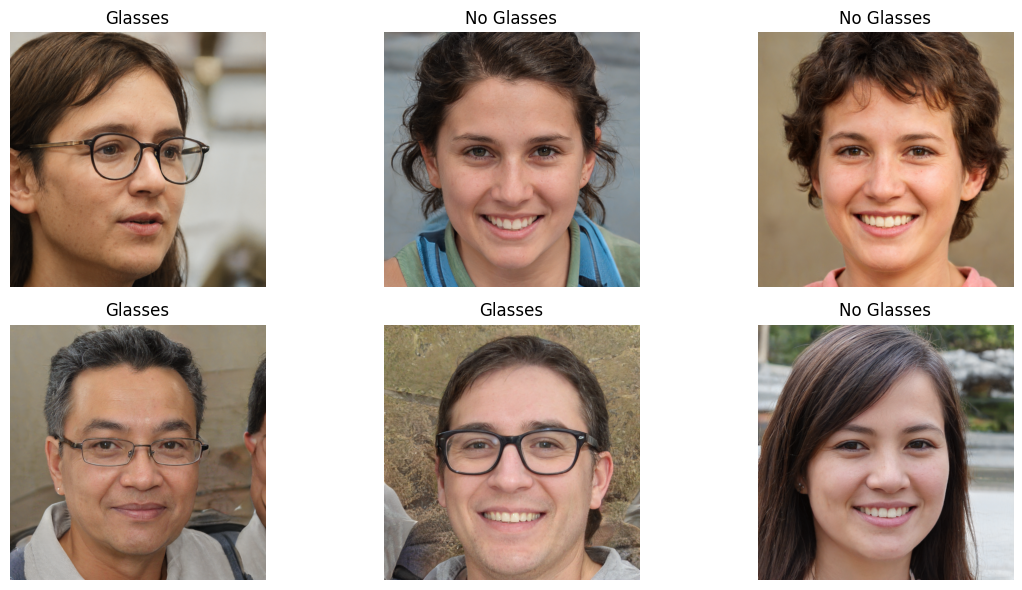

In [ ]:
# Display sample images with labels
import matplotlib.pyplot as plt
from PIL import Image

sample_df = train_df.sample(6, random_state=42)

plt.figure(figsize=(12, 6))

for i, row in enumerate(sample_df.itertuples(), 1):
    img = Image.open(row.image_path)

    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.axis("off")

    label_name = "Glasses" if row.glasses == 1 else "No Glasses"
    plt.title(label_name)

plt.tight_layout()
plt.show()

In [ ]:
# Convert numeric labels to text labels for ImageDataGenerator
train_df["label"] = train_df["glasses"].apply(lambda x: "Glasses" if x == 1 else "No_Glasses")

# Display first 5 rows
train_df[["id", "filename", "glasses", "label"]].head()

,id,filename,glasses,label
0,1,face-1.png,0,No_Glasses
1,2,face-2.png,1,Glasses
2,3,face-3.png,1,Glasses
3,4,face-4.png,0,No_Glasses
4,5,face-5.png,0,No_Glasses


In [ ]:
# Split the dataset into training and validation sets
from sklearn.model_selection import train_test_split

train_data, val_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    stratify=train_df["label"]
)

print("Training data shape:", train_data.shape)
print("Validation data shape:", val_data.shape)

print("\nTraining label distribution:")
print(train_data["label"].value_counts())

print("\nValidation label distribution:")
print(val_data["label"].value_counts())

Training data shape: (3600, 518)
Validation data shape: (900, 518)

Training label distribution:
label
Glasses       2285
No_Glasses    1315
Name: count, dtype: int64

Validation label distribution:
label
Glasses       571
No_Glasses    329
Name: count, dtype: int64


In [ ]:
# Import ImageDataGenerator for image preprocessing
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image settings
IMG_SIZE = 224
BATCH_SIZE = 32

# Data generator for training with augmentation
train_generator = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

# Data generator for validation without augmentation
val_generator = ImageDataGenerator(
    rescale=1./255
)

In [ ]:
# Create training image data
train_images = train_generator.flow_from_dataframe(
    dataframe=train_data,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

# Create validation image data
val_images = val_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 3600 validated image filenames belonging to 2 classes.
Found 900 validated image filenames belonging to 2 classes.


In [ ]:
# Check class indices
print("Class indices:")
print(train_images.class_indices)

Class indices:
{'Glasses': 0, 'No_Glasses': 1}


In [ ]:
# Import TensorFlow and Keras layers
import tensorflow as tf
from tensorflow.keras import layers, models

In [ ]:
# Build CNN model from scratch
cnn_model = models.Sequential([
    # First convolution block
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.MaxPooling2D((2, 2)),

    # Second convolution block
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Third convolution block
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # Convert feature maps to one vector
    layers.Flatten(),

    # Fully connected layer
    layers.Dense(128, activation="relu"),

    # Dropout to reduce overfitting
    layers.Dropout(0.5),

    # Output layer for binary classification
    layers.Dense(1, activation="sigmoid")
])

# Show model architecture
cnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile CNN model
cnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train CNN model
history_cnn = cnn_model.fit(
    train_images,
    validation_data=val_images,
    epochs=10
)

Epoch 1/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 692s 6s/step - accuracy: 0.8078 - loss: 0.4221 - val_accuracy: 0.8767 - val_loss: 0.4247
Epoch 2/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 674s 6s/step - accuracy: 0.8681 - loss: 0.3330 - val_accuracy: 0.8733 - val_loss: 0.3686
Epoch 3/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 667s 6s/step - accuracy: 0.8697 - loss: 0.3196 - val_accuracy: 0.8733 - val_loss: 0.3209
Epoch 4/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 665s 6s/step - accuracy: 0.8742 - loss: 0.3164 - val_accuracy: 0.8867 - val_loss: 0.3129
Epoch 5/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 657s 6s/step - accuracy: 0.8806 - loss: 0.3142 - val_accuracy: 0.8778 - val_loss: 0.3145
Epoch 6/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 657s 6s/step - accuracy: 0.8825 - loss: 0.3006 - val_accuracy: 0.8789 - val_loss: 0.2877
Epoch 7/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 652s 6s/step - accuracy: 0.8808 - loss: 0.3023 - val_accuracy: 0.8767 - val_loss: 0.2924
Epoch 8/10
113/113 ━━━━━━━━━━━━━━━━━━━━ 656s 6s/step - accuracy: 0.8819 - loss: 0.3022 - val_accu

In [ ]:
# Evaluate CNN model on validation data
cnn_loss, cnn_accuracy = cnn_model.evaluate(val_images)

print("CNN Validation Loss:", cnn_loss)
print("CNN Validation Accuracy:", cnn_accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 69s 2s/step - accuracy: 0.8856 - loss: 0.2982
CNN Validation Loss: 0.29822322726249695
CNN Validation Accuracy: 0.8855555653572083


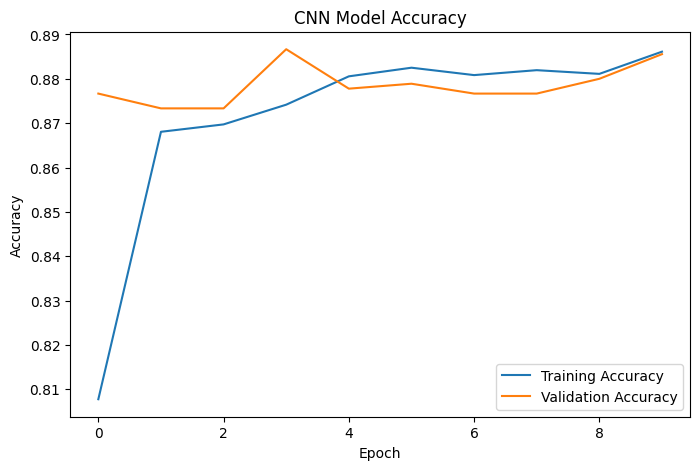

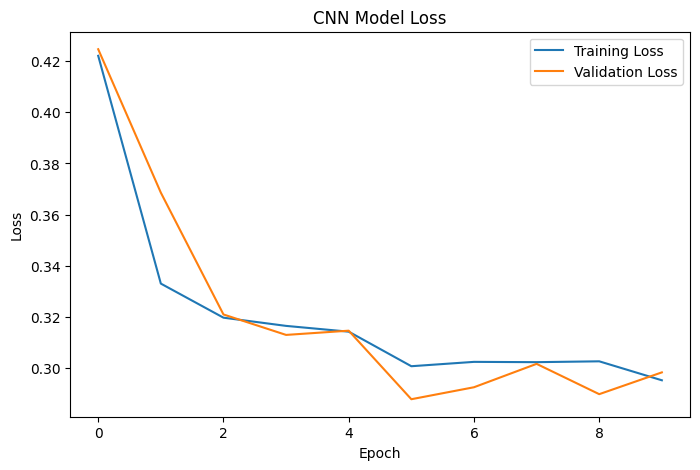

In [ ]:
# Plot CNN training and validation accuracy
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["accuracy"], label="Training Accuracy")
plt.plot(history_cnn.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot CNN training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(history_cnn.history["loss"], label="Training Loss")
plt.plot(history_cnn.history["val_loss"], label="Validation Loss")
plt.title("CNN Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [ ]:
# Import MobileNetV2 pre-trained model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

In [ ]:
# Data generator for MobileNetV2 preprocessing
mobilenet_train_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

mobilenet_val_generator = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [ ]:
# Create MobileNetV2 training image data
mobilenet_train_images = mobilenet_train_generator.flow_from_dataframe(
    dataframe=train_data,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=True
)

# Create MobileNetV2 validation image data
mobilenet_val_images = mobilenet_val_generator.flow_from_dataframe(
    dataframe=val_data,
    x_col="image_path",
    y_col="label",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 3600 validated image filenames belonging to 2 classes.
Found 900 validated image filenames belonging to 2 classes.


In [ ]:
# Load MobileNetV2 without the final classification layer
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

# Freeze the base model layers
base_model.trainable = False

# Build the final model
mobilenet_model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

# Show model architecture
mobilenet_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# Compile MobileNetV2 model
mobilenet_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Train MobileNetV2 model
history_mobilenet = mobilenet_model.fit(
    mobilenet_train_images,
    validation_data=mobilenet_val_images,
    epochs=5
)

Epoch 1/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 460s 4s/step - accuracy: 0.8189 - loss: 0.4243 - val_accuracy: 0.8667 - val_loss: 0.3093
Epoch 2/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 443s 4s/step - accuracy: 0.8622 - loss: 0.3238 - val_accuracy: 0.8744 - val_loss: 0.2948
Epoch 3/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 445s 4s/step - accuracy: 0.8700 - loss: 0.3051 - val_accuracy: 0.8700 - val_loss: 0.2983
Epoch 4/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 447s 4s/step - accuracy: 0.8686 - loss: 0.3046 - val_accuracy: 0.8644 - val_loss: 0.3095
Epoch 5/5
113/113 ━━━━━━━━━━━━━━━━━━━━ 435s 4s/step - accuracy: 0.8725 - loss: 0.2887 - val_accuracy: 0.8722 - val_loss: 0.2916


In [ ]:
# Evaluate MobileNetV2 model on validation data
mobilenet_loss, mobilenet_accuracy = mobilenet_model.evaluate(mobilenet_val_images)

print("MobileNetV2 Validation Loss:", mobilenet_loss)
print("MobileNetV2 Validation Accuracy:", mobilenet_accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 85s 3s/step - accuracy: 0.8722 - loss: 0.2916
MobileNetV2 Validation Loss: 0.2916397750377655
MobileNetV2 Validation Accuracy: 0.8722222447395325


In [ ]:
# Create a comparison table between CNN and MobileNetV2
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["CNN from Scratch", "MobileNetV2"],
    "Validation Loss": [cnn_loss, mobilenet_loss],
    "Validation Accuracy": [cnn_accuracy, mobilenet_accuracy]
})

display(comparison_df)

,Model,Validation Loss,Validation Accuracy
0,CNN from Scratch,0.298223,0.885556
1,MobileNetV2,0.291640,0.872222


In [ ]:
# Generate predictions using CNN model
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

# Reset validation generator
val_images.reset()

# Predict probabilities
cnn_predictions = cnn_model.predict(val_images)

# Convert probabilities to class labels
cnn_pred_classes = (cnn_predictions > 0.5).astype("int32").flatten()

# True labels
true_classes = val_images.classes
# Class names
class_names = list(val_images.class_indices.keys())

print("CNN Classification Report:")
print(classification_report(true_classes, cnn_pred_classes, target_names=class_names))

29/29 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step
CNN Classification Report:
              precision    recall  f1-score   support

     Glasses       0.96      0.86      0.91       571
  No_Glasses       0.79      0.93      0.86       329

    accuracy                           0.89       900
   macro avg       0.87      0.89      0.88       900
weighted avg       0.90      0.89      0.89       900



In [ ]:
# Generate predictions using MobileNetV2 model
mobilenet_val_images.reset()

# Predict probabilities
mobilenet_predictions = mobilenet_model.predict(mobilenet_val_images)

# Convert probabilities to class labels
mobilenet_pred_classes = (mobilenet_predictions > 0.5).astype("int32").flatten()

# True labels
mobilenet_true_classes = mobilenet_val_images.classes

# Class names
mobilenet_class_names = list(mobilenet_val_images.class_indices.keys())

print("MobileNetV2 Classification Report:")
print(classification_report(mobilenet_true_classes, mobilenet_pred_classes, target_names=mobilenet_class_names))

29/29 ━━━━━━━━━━━━━━━━━━━━ 101s 3s/step
MobileNetV2 Classification Report:
              precision    recall  f1-score   support

     Glasses       0.94      0.86      0.89       571
  No_Glasses       0.78      0.90      0.84       329

    accuracy                           0.87       900
   macro avg       0.86      0.88      0.87       900
weighted avg       0.88      0.87      0.87       900



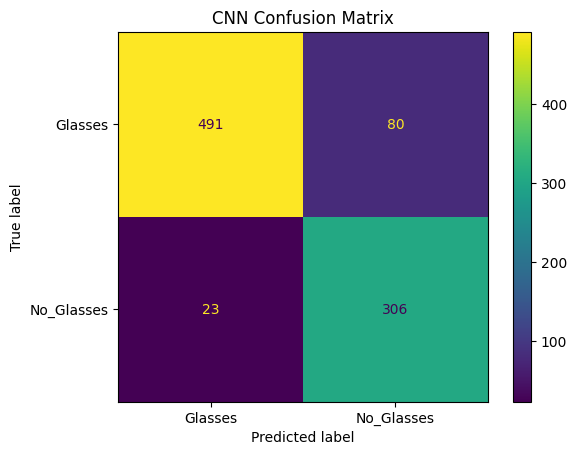

In [ ]:
# Confusion Matrix for CNN model
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cnn_cm = confusion_matrix(true_classes, cnn_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=cnn_cm, display_labels=class_names)
disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

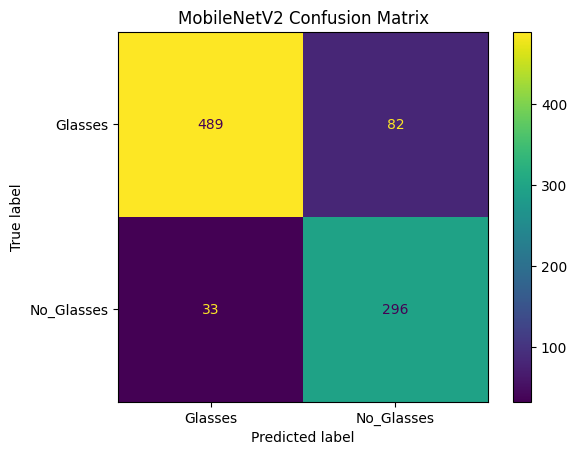

In [ ]:
# Confusion Matrix for MobileNetV2 model
mobilenet_cm = confusion_matrix(mobilenet_true_classes, mobilenet_pred_classes)

disp = ConfusionMatrixDisplay(confusion_matrix=mobilenet_cm, display_labels=mobilenet_class_names)
disp.plot()
plt.title("MobileNetV2 Confusion Matrix")
plt.show()

In [ ]:
# Final results summary
print("Final Model Comparison")
print("----------------------")
print("CNN Validation Accuracy:", round(cnn_accuracy, 4))
print("CNN Validation Loss:", round(cnn_loss, 4))
print("MobileNetV2 Validation Accuracy:", round(mobilenet_accuracy, 4))
print("MobileNetV2 Validation Loss:", round(mobilenet_loss, 4))

if cnn_accuracy > mobilenet_accuracy:
    print("\nBest Model: CNN from Scratch")
else:
    print("\nBest Model: MobileNetV2")

Final Model Comparison
----------------------
CNN Validation Accuracy: 0.8856
CNN Validation Loss: 0.2982
MobileNetV2 Validation Accuracy: 0.8722
MobileNetV2 Validation Loss: 0.2916

Best Model: CNN from Scratch


In [ ]:
# Save the best performing model
cnn_model.save("best_glasses_classification_cnn_model.h5")

print("Best CNN model saved successfully.")

Best CNN model saved successfully.


## Conclusion

In this project, a binary image classification system was developed to classify face images into two categories: Glasses and No_Glasses. The dataset was downloaded from Kaggle and prepared using image paths and class labels from the training CSV file. The images were resized to 224 × 224 pixels and processed using data augmentation techniques such as rotation, zooming, and horizontal flipping to reduce overfitting.

Two deep learning models were implemented and compared. The first model was a Convolutional Neural Network built from scratch, while the second model used MobileNetV2 as a pre-trained transfer learning model. The CNN model achieved a validation accuracy of approximately 88.56%, while MobileNetV2 achieved approximately 87.22%. Based on these results, the CNN model performed slightly better for this dataset.

The results show that CNNs are effective for binary image classification tasks. Future improvements could include fine-tuning the MobileNetV2 layers, using more epochs, applying stronger augmentation, or testing other pre-trained models such as VGG16, ResNet50, or EfficientNet.